
# Experimental universal Scaled Spectra for Pb+Pb 2.76 TeV and Xe+Xe 5.44 TeV

This notebook reads the spectra tables directly from local folders (PbPb276/HEPData-ins1222333-v1-csv/ and XeXe544/HEPData-ins1840099-v1-csv/).

1. Extracts the $p_T$ distributions, total yields N and mean transverse momenta $\langle p_T \rangle$. 

2. Computes the universal scaling variables

$x_T = \frac{p_T}{\langle p_T \rangle}$

$U(x_T)
=
\frac{\langle p_T \rangle}{N}
\frac{dN}{dp_T}$


3. Plot the universal scaled spectra for:
   - pions
   - kaons
   - protons

for:
- Pb+Pb at 2.76 TeV
- Xe+Xe at 5.44 TeV

### 1.  Helper functions to read the CSV tables


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import os, csv

# Base paths – adjust if your folders are elsewhere
BASE_PbPb = os.path.join("PbPb276", "HEPData-ins1222333-v1-csv")
BASE_XeXe = os.path.join("XeXe544", "HEPData-ins1840099-v1-csv")

## Pb+Pb 2.76 TeV

### 1.1  Reader for Pb–Pb 2.76 TeV spectra
 
The raw data are given as $\frac{1}{2\pi p_T}\frac{d^2 N}{d\eta dp_T}$. We must multiply by $2\pi p_T$ and by the rapidity interval $\Delta y=1.0$ $|y|<0.5$ to obtain $dN/dp_T$. Positive and negative particles are stored in the same file; we combine them.  

Tables are organised as:
- Pions: `Table1.csv` … `Table10.csv` (centralities 0‑5% … 80‑90%)
- Kaons: `Table11.csv` … `Table20.csv`
- Protons: `Table21.csv` … `Table30.csv`

In [12]:
def read_PbPb276_spectra(particle, centrality_indices=None):
    """
    Read the Pb–Pb 2.76 TeV spectra for a given particle.
    Returns: list of pT centres, list of bin widths, list of dN/dpT,
             list of statistical errors, list of total errors.
    """
    # Mapping
    offset = {'pion': 0, 'kaon': 10, 'proton': 20}
    n_centralities = 10
    if centrality_indices is None:
        centrality_indices = list(range(n_centralities))
    
    # Number of data points per charge and negative block start (0‑based index)
    particle_params = {
        'pion':  {'n_bins': 41, 'neg_start': 61},
        'kaon':  {'n_bins': 36, 'neg_start': 56},
        'proton':{'n_bins': 42, 'neg_start': 62}
    }
    n_pts = particle_params[particle]['n_bins']
    neg_start = particle_params[particle]['neg_start']
    
    pT_centers_all = []
    widths_all = []
    dNdpT_all = []
    stat_all = []
    tot_all = []
    
    for idx, i_cent in enumerate(centrality_indices):
        table_num = i_cent + offset[particle] + 1
        file_path = os.path.join(BASE_PbPb, f"Table{table_num}.csv")
        with open(file_path, 'r') as f:
            lines = list(csv.reader(f))
        
        # Helper to extract one charge block (positive or negative)
        def extract_block(start_line, n_points):
            pT = []; widths = []; vals = []; stat = []; sys = []
            for j in range(start_line, start_line + n_points):
                row = lines[j]
                c = float(row[0])           # bin centre
                lo = float(row[1])
                hi = float(row[2])
                val = float(row[3])         # 1/(2π pT) d²N/(dη dpT)
                stat_err = float(row[4])
                sys_err = float(row[6])     # absolute systematic
                norm_pct = float(row[8].replace('%', ''))
                pT.append(c)
                widths.append(hi - lo)
                # Multiply by 2π pT → d²N/(dη dpT)
                val = val * 2 * np.pi * c
                stat_err = stat_err * 2 * np.pi * c
                sys_err = sys_err * 2 * np.pi * c
                # Add normalisation uncertainty
                norm = norm_pct * 0.01 * val
                tot = np.sqrt(stat_err**2 + sys_err**2 + norm**2)
                vals.append(val)
                stat.append(stat_err)
                sys.append(tot)   # store total in 'sys' for now
            return np.array(pT), np.array(widths), np.array(vals), np.array(stat), np.array(sys)
        
        # Positive particles always start at line 15 (index 14)
        pos_pT, pos_w, pos_v, pos_stat, pos_tot = extract_block(14, n_pts)
        # Negative particles start at the particle‑dependent index
        neg_pT, neg_w, neg_v, neg_stat, neg_tot = extract_block(neg_start, n_pts)
        
        # Combine charges
        pT = pos_pT   # same bins
        widths = pos_w
        d2N_detadpt = pos_v + neg_v
        stat_err = np.sqrt(pos_stat**2 + neg_stat**2)
        tot_err = np.sqrt(pos_tot**2 + neg_tot**2)
        
        # Multiply by Δy = 1.0 → dN/dpT
        dNdpT = d2N_detadpt * 1.0
        stat_err = stat_err * 1.0
        tot_err = tot_err * 1.0
        
        pT_centers_all.append(pT)
        widths_all.append(widths)
        dNdpT_all.append(dNdpT)
        stat_all.append(stat_err)
        tot_all.append(tot_err)
    
    return pT_centers_all, widths_all, dNdpT_all, stat_all, tot_all

### 1.2  Reader for Pb–Pb 2.76 TeV extrapolated quantities

Total multiplicities $N$ and mean $p_T$ are stored in `Table31.csv` and `Table32.csv`. Positive and negative particles are given separately.

In [3]:
def read_PbPb276_extrapolated(particle):
    """Return N, N_err, meanpT, mpt_err for all 10 centralities."""
    # Multiplicity
    mult_path = os.path.join(BASE_PbPb, "Table31.csv")
    with open(mult_path, 'r') as f:
        lines = list(csv.reader(f))
    # pion: positive rows 29-38 (idx 28-37), negative 44-53 (idx 43-52)
    # kaon: pos 59-68 (58-67), neg 74-83 (73-82)
    # proton: pos 89-98 (88-97), neg 104-113 (103-112)
    ranges = {'pion': [(28,38), (43,53)],
              'kaon': [(58,68), (73,83)],
              'proton': [(88,98), (103,113)]}
    pos_range, neg_range = ranges[particle]
    pos_mult = [float(lines[i][3]) for i in range(pos_range[0], pos_range[1])]
    neg_mult = [float(lines[i][3]) for i in range(neg_range[0], neg_range[1])]
    pos_mult_err = [float(lines[i][4]) for i in range(pos_range[0], pos_range[1])]
    neg_mult_err = [float(lines[i][4]) for i in range(neg_range[0], neg_range[1])]
    N = np.array(pos_mult) + np.array(neg_mult)
    N_err = np.sqrt(np.array(pos_mult_err)**2 + np.array(neg_mult_err)**2)
    
    # Mean pT
    mpt_path = os.path.join(BASE_PbPb, "Table32.csv")
    with open(mpt_path, 'r') as f:
        lines = list(csv.reader(f))
    # pion: pos 14-23 (13-22), neg 29-38 (28-37)
    # kaon: pos 44-53 (43-52), neg 59-68 (58-67)
    # proton: pos 74-83 (73-82), neg 89-98 (88-97)
    mpt_ranges = {'pion': [(13,23), (28,38)],
                  'kaon': [(43,53), (58,68)],
                  'proton': [(73,83), (88,98)]}
    pos_r, neg_r = mpt_ranges[particle]
    pos_mpt = [float(lines[i][3]) for i in range(pos_r[0], pos_r[1])]
    neg_mpt = [float(lines[i][3]) for i in range(neg_r[0], neg_r[1])]
    pos_mpt_err = [float(lines[i][4]) for i in range(pos_r[0], pos_r[1])]
    neg_mpt_err = [float(lines[i][4]) for i in range(neg_r[0], neg_r[1])]
    meanpT = (np.array(pos_mpt) + np.array(neg_mpt)) / 2
    mpt_err = np.sqrt(np.array(pos_mpt_err)**2 + np.array(neg_mpt_err)**2) / 2
    
    return N, N_err, meanpT, mpt_err

### 2.  Step‑by‑step example: Pb–Pb 2.76 TeV pions, 0‑5% centrality

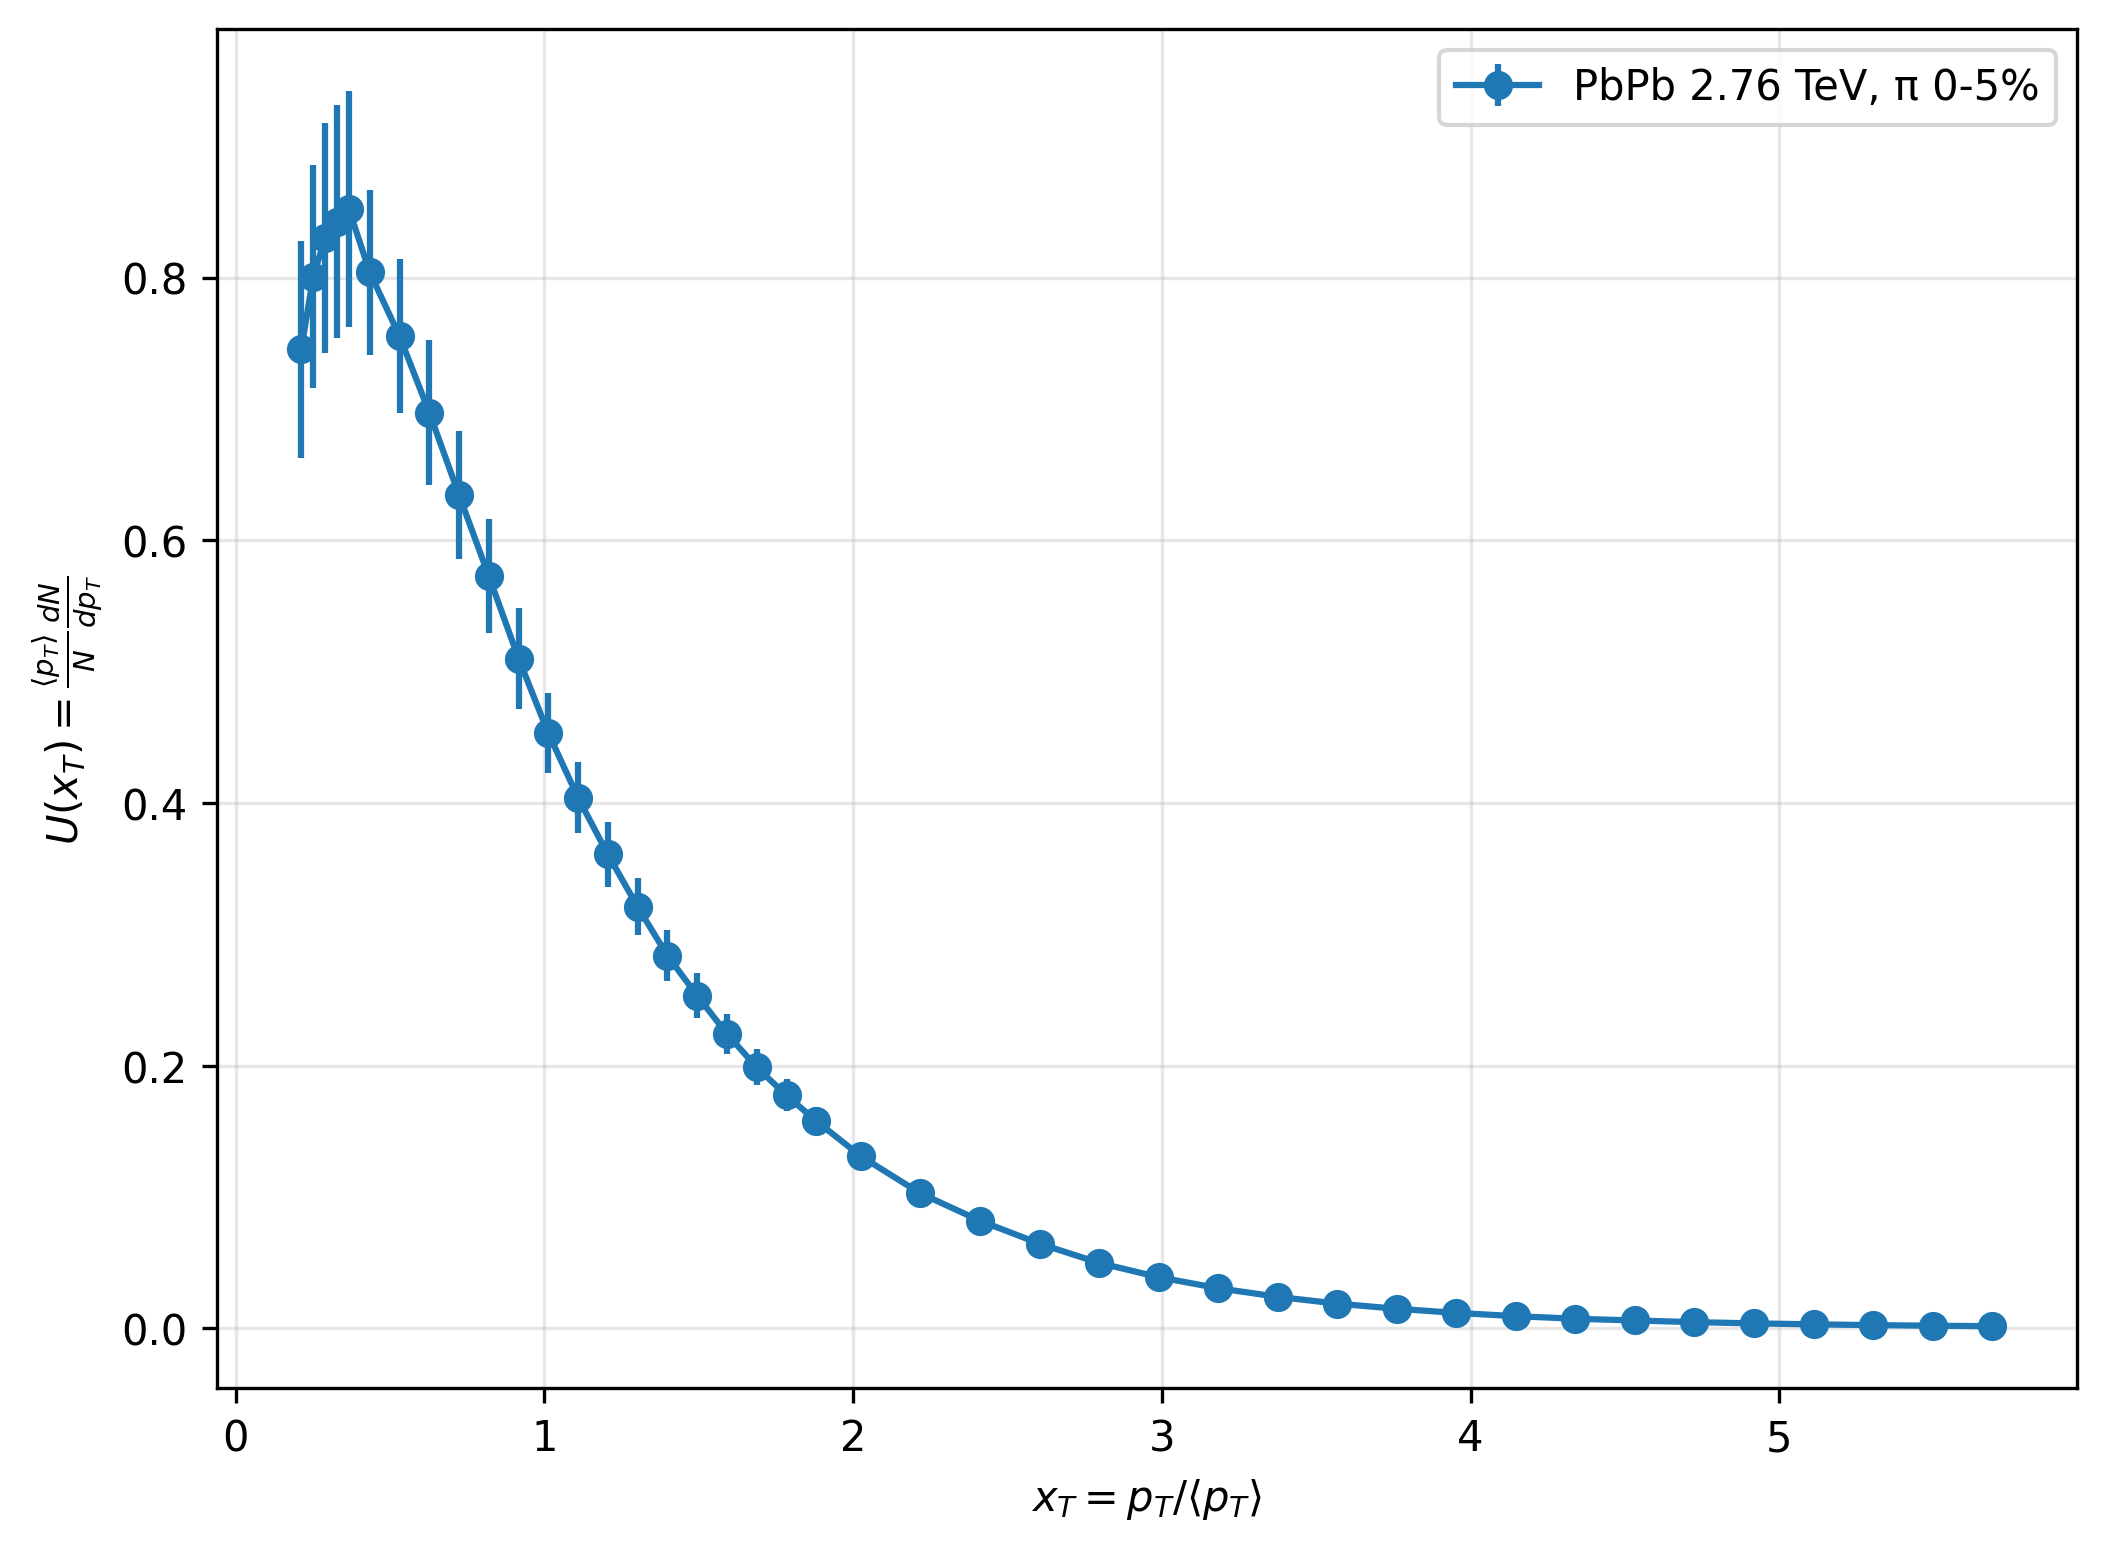

In [8]:
# %%
# Choose particle and a single centrality
particle = 'pion'
cent_index = [0]   # 0‑5%

# Read spectra and extrapolated numbers
pT_list, widths, dNdpT_list, stat, tot = read_PbPb276_spectra(particle, cent_index)
N, N_err, meanpT, mpt_err = read_PbPb276_extrapolated(particle)

# Extract the first (and only) centrality
pT = pT_list[0]
dNdpT = dNdpT_list[0]
N0 = N[0]
mpt0 = meanpT[0]

# Build scaling variables
xT = pT / mpt0
U = (mpt0 / N0) * dNdpT
U_err = U * np.sqrt((tot[0]/dNdpT)**2 + (N_err[0]/N0)**2 + (mpt_err[0]/mpt0)**2)

# Quick plot
plt.figure(figsize=(8,6), dpi=300)
plt.errorbar(xT, U, yerr=U_err, fmt='o-', label='PbPb 2.76 TeV, π 0-5%')
plt.xlabel(r'$x_T = p_T / \langle p_T \rangle$')
plt.ylabel(r'$U(x_T) = \frac{\langle p_T \rangle}{N} \frac{dN}{dp_T}$')
#plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.  Functions to compute universal scaling for all centralities

In [9]:
def universal_scaling_PbPb276(particle, cent_indices=None):
    if cent_indices is None:
        cent_indices = list(range(10))
    pT_list, widths, dNdpT_list, stat, tot = read_PbPb276_spectra(particle, cent_indices)
    N, N_err, meanpT, mpt_err = read_PbPb276_extrapolated(particle)
    results = {}
    cent_labels = [f"{i*10}-{(i+1)*10}%" for i in range(10)]
    for idx, i in enumerate(cent_indices):
        pT = pT_list[idx]
        dNdpT = dNdpT_list[idx]
        Ni = N[i]
        mpt_i = meanpT[i]
        xT = pT / mpt_i
        U = (mpt_i / Ni) * dNdpT
        dU = U * np.sqrt((tot[idx]/dNdpT)**2 + (N_err[i]/Ni)**2 + (mpt_err[i]/mpt_i)**2)
        results[i] = {'xT': xT, 'U': U, 'U_err': dU, 'centrality': cent_labels[i]}
    return results

def universal_scaling_XeXe(particle, cent_indices=None):
    if cent_indices is None:
        cent_indices = list(range(9))
    pT_list, widths, dNdpT_list, stat, tot = read_XeXe_spectra(particle, cent_indices)
    N, N_err, meanpT, mpt_err = XeXe_extrapolated_values(particle)
    cent_labels = ["0-5%", "5-10%", "10-20%", "20-30%", "30-40%",
                   "40-50%", "50-60%", "60-70%", "70-90%"]
    results = {}
    for idx, i in enumerate(cent_indices):
        pT = pT_list[idx]
        dNdpT = dNdpT_list[idx]
        Ni = N[i]
        mpt_i = meanpT[i]
        xT = pT / mpt_i
        U = (mpt_i / Ni) * dNdpT
        dU = U * np.sqrt((tot[idx]/dNdpT)**2 + (N_err[i]/Ni)**2 + (mpt_err[i]/mpt_i)**2)
        results[i] = {'xT': xT, 'U': U, 'U_err': dU, 'centrality': cent_labels[i]}
    return results

### 4.  All centralities and hadronic species for Pb+Pb 2.76 TeV
Three figures side‑by‑side for pions, kaons, protons.


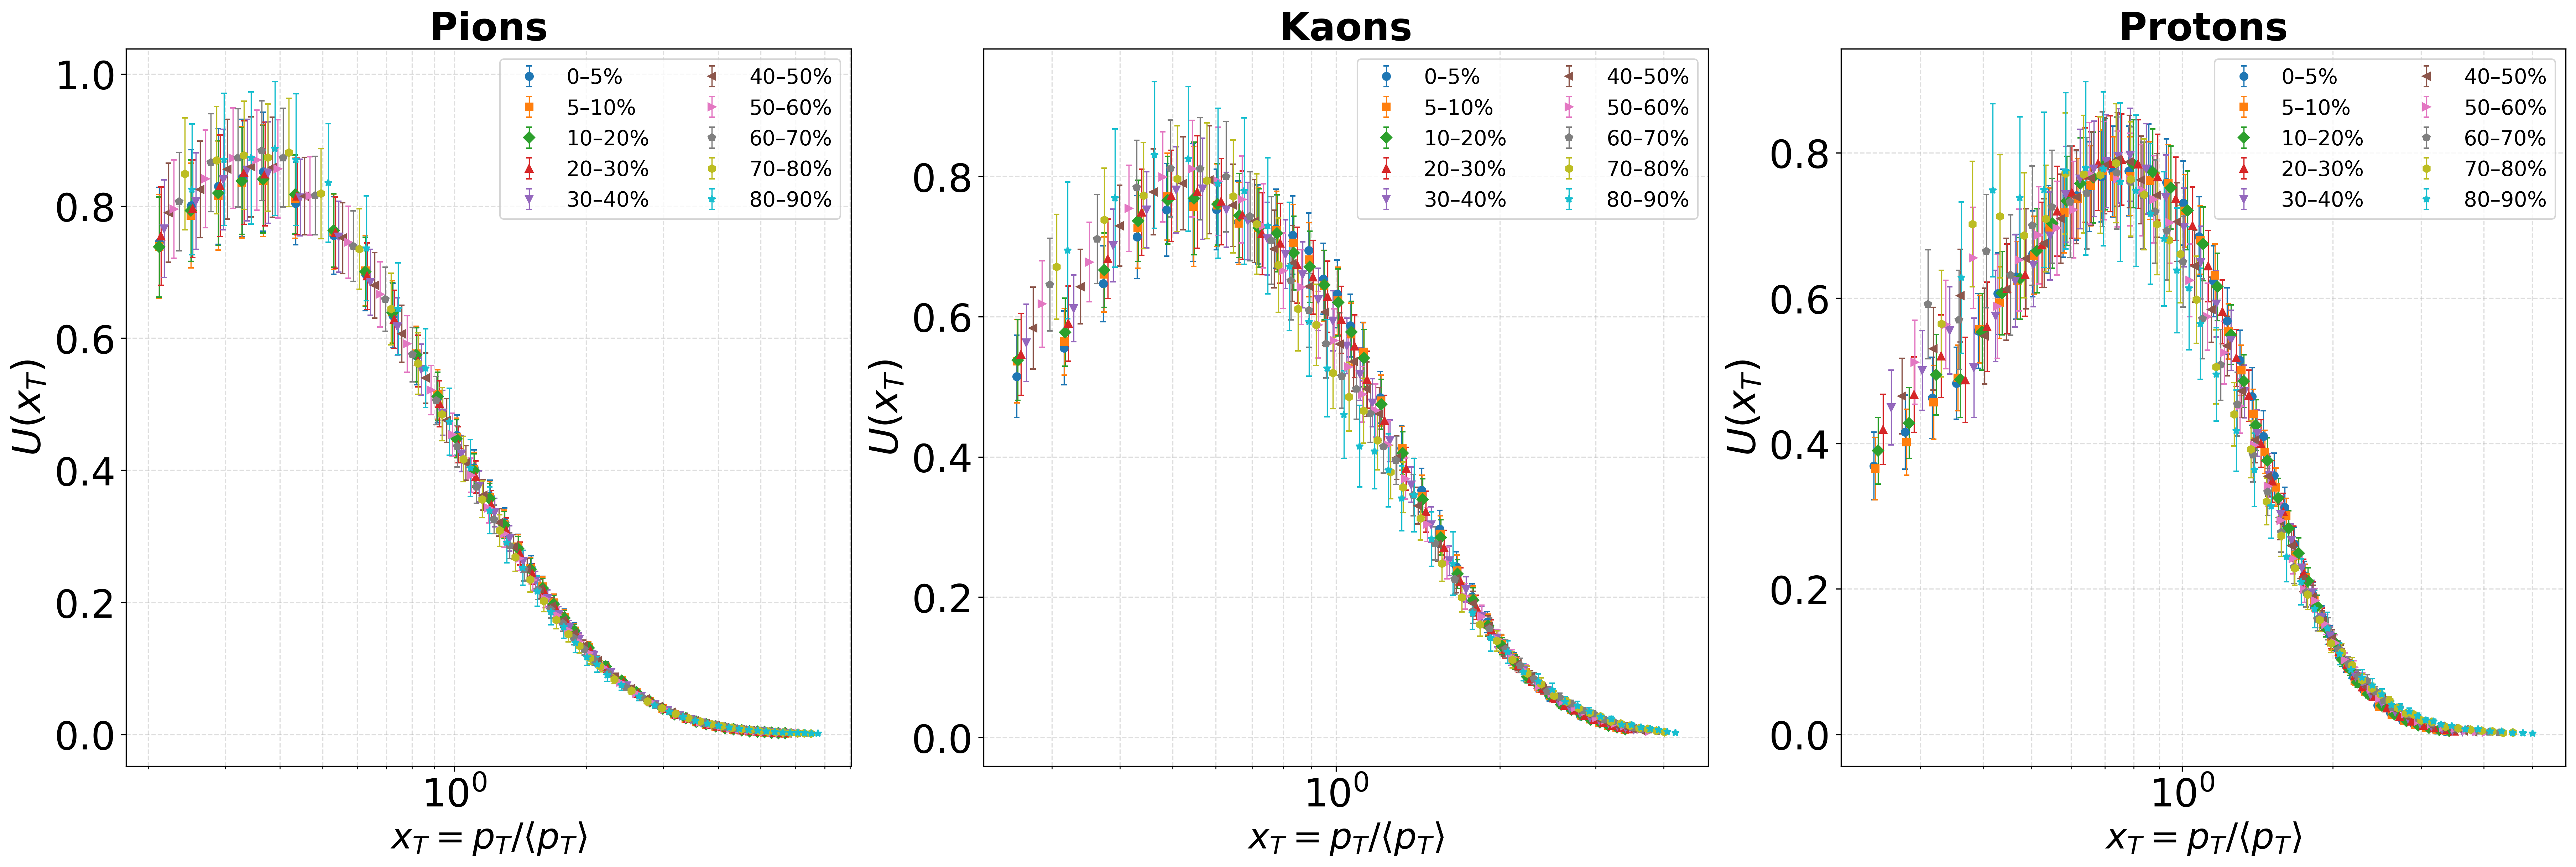

In [22]:
# %%
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

particles = ['pion', 'kaon', 'proton']
# Full centrality labels for PbPb 2.76 TeV (10 classes)
centrality_labels = [
    "0–5%", "5–10%", "10–20%", "20–30%", "30–40%",
    "40–50%", "50–60%", "60–70%", "70–80%", "80–90%"
]

# Define a set of distinct markers (one per centrality)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*']
# Colour cycle (use a qualitative colormap)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300, constrained_layout=True)

for ax, part in zip(axes, particles):
    # PbPb 2.76 TeV
    data_pb = universal_scaling_PbPb276(part)
    
    # Plot each centrality with its own marker and color
    for i, d in data_pb.items():
        ax.errorbar(d['xT'], d['U'], yerr=d['U_err'],
                    fmt=markers[i], color=colors[i],
                    markersize=5, capsize=2, linewidth=0.8,
                    label=centrality_labels[i])
    
    ax.set_xscale('log')
#    ax.set_yscale('log')
    ax.set_xlabel(r'$x_T = p_T / \langle p_T \rangle$', fontsize=24)
    ax.set_ylabel(r'$U(x_T)$', fontsize=26)
    ax.set_title(f'{part.capitalize()}s', fontsize=26, fontweight='bold')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=26)
    
    # Legend: show all centralities inside the plot
    ax.legend(fontsize=14, loc='best', ncol=2, frameon=True, fancybox=True)

plt.show()

### **Validation:** plot each piece of U(x_T)

Experimental $\langle p_T \rangle$ vs centrality for Pb+Pb 2.76 TeV

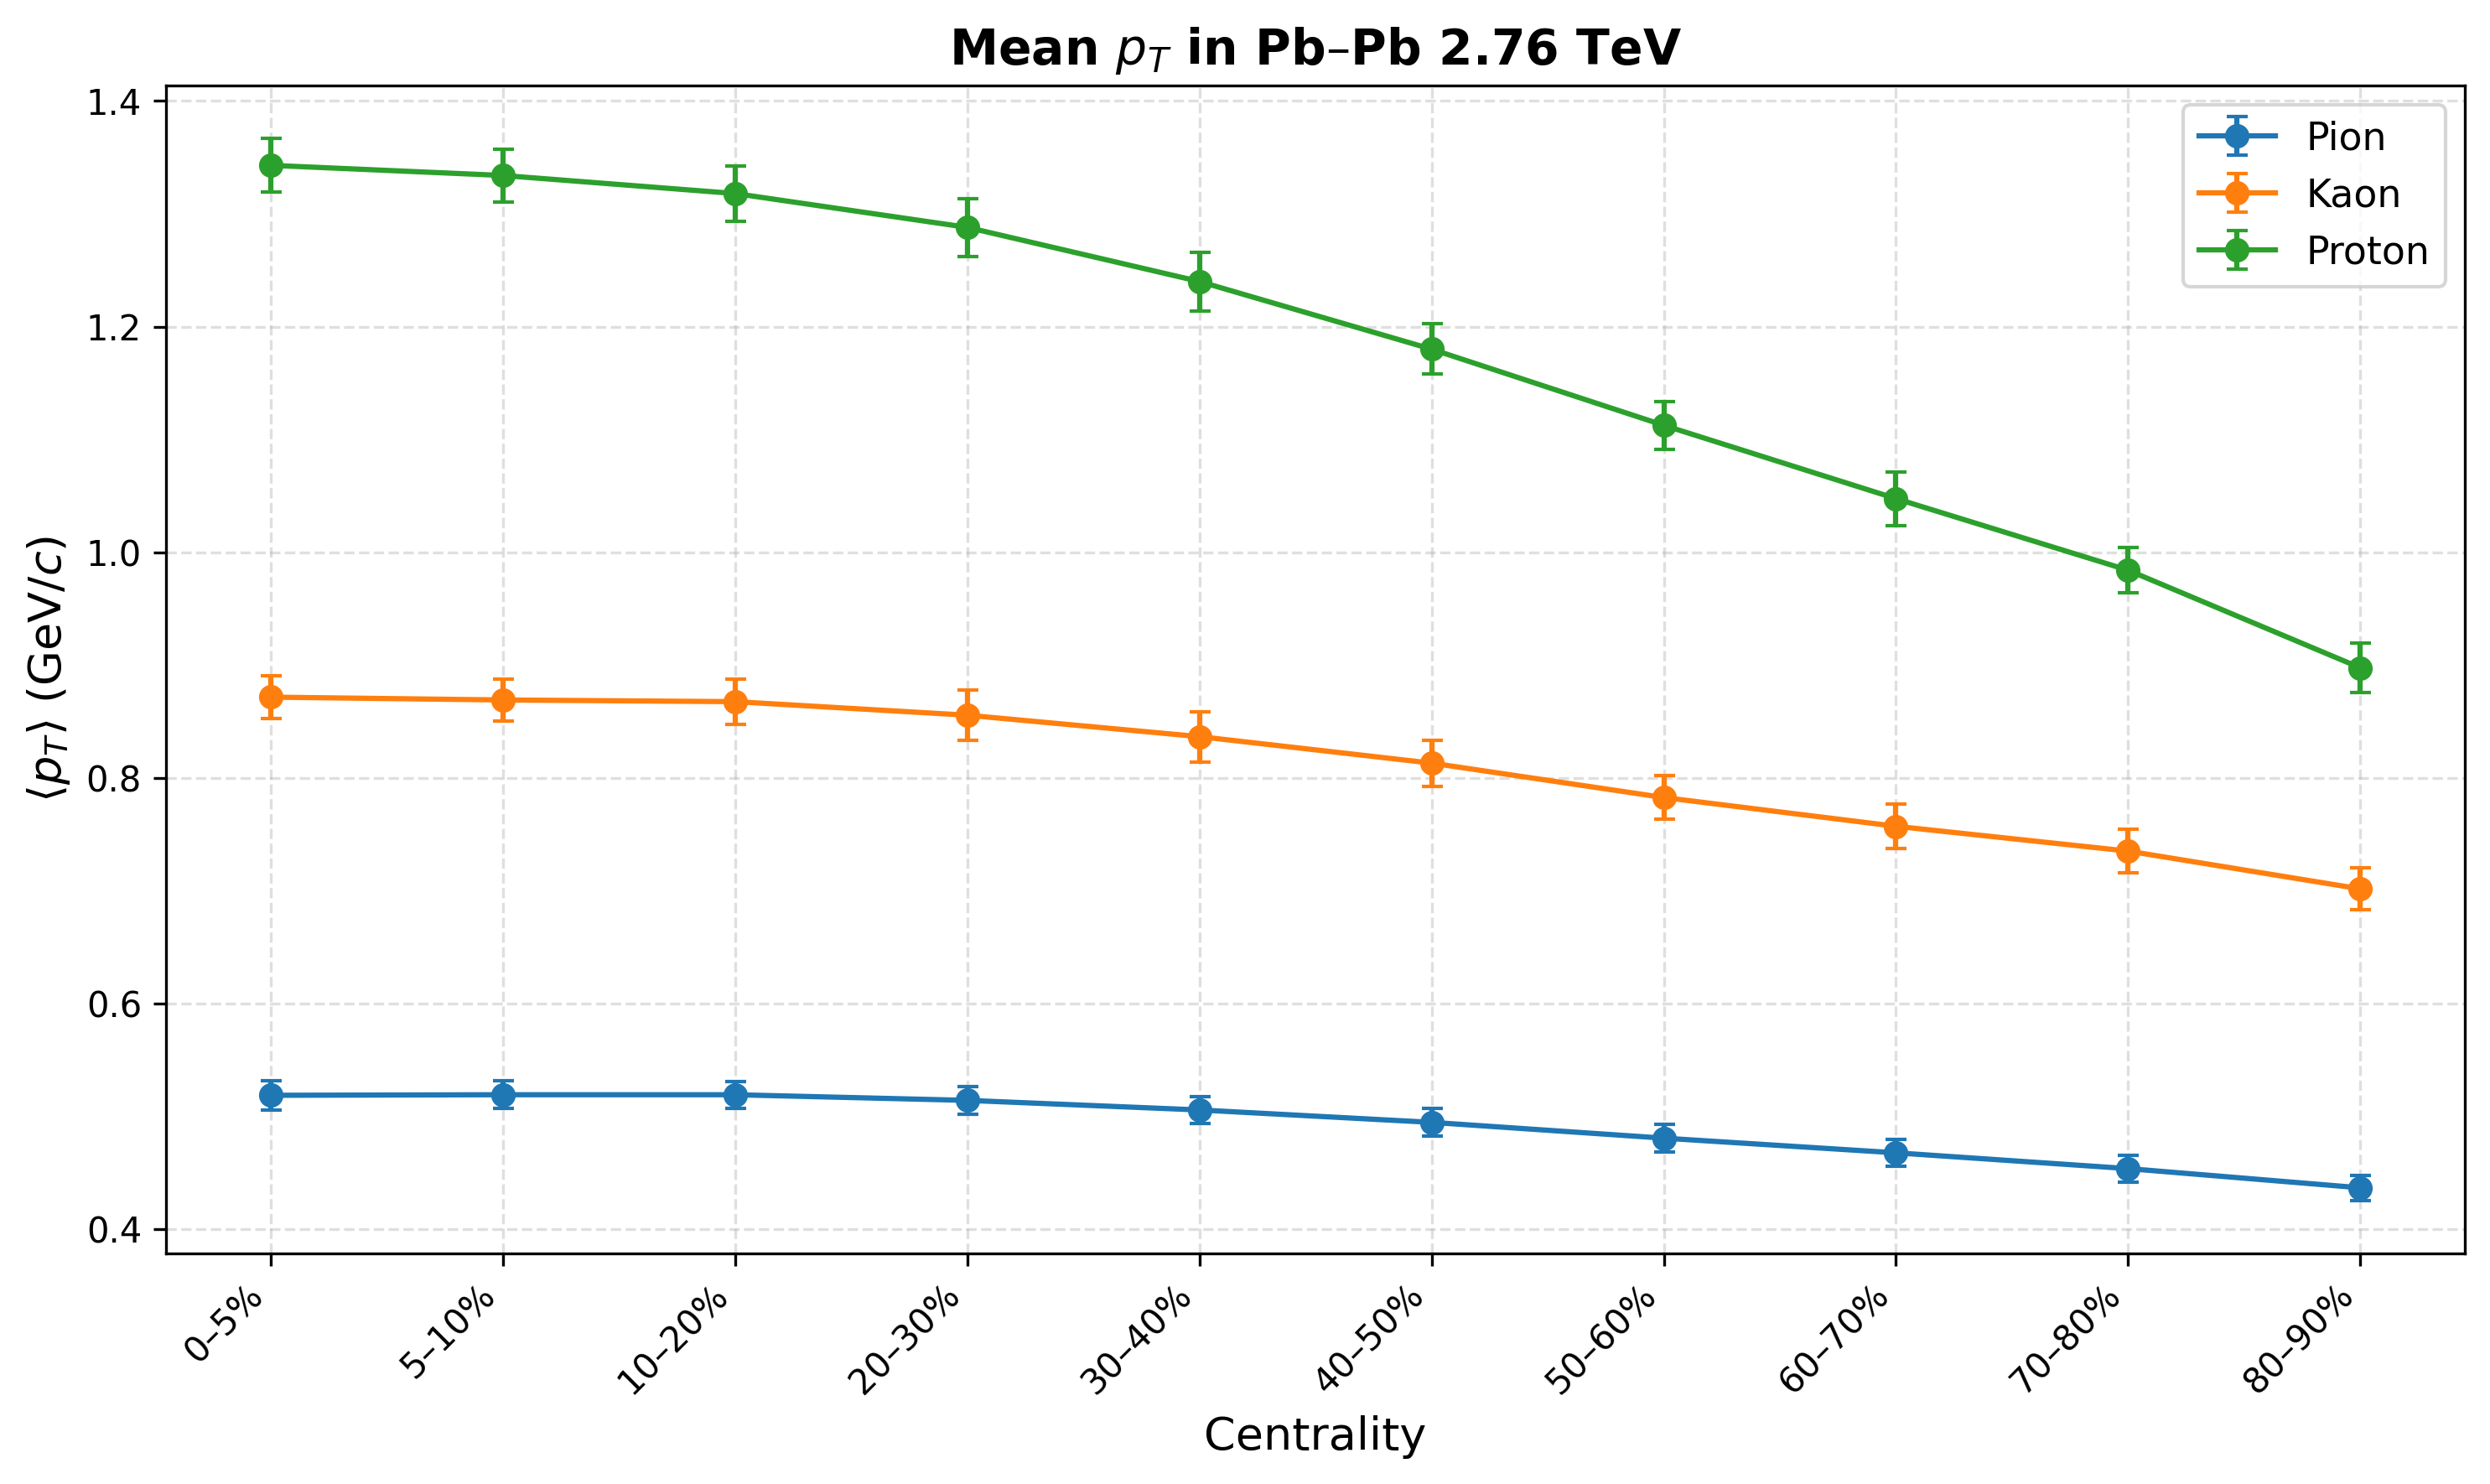

In [23]:
import matplotlib.pyplot as plt
import numpy as np

particles = ['pion', 'kaon', 'proton']
centrality_labels = [
    "0–5%", "5–10%", "10–20%", "20–30%", "30–40%",
    "40–50%", "50–60%", "60–70%", "70–80%", "80–90%"
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x = np.arange(len(centrality_labels))  # just indices for equal spacing

for part in particles:
    N, N_err, mpt, mpt_err = read_PbPb276_extrapolated(part)
    ax.errorbar(x, mpt, yerr=mpt_err, fmt='o-', capsize=3, label=part.capitalize())

ax.set_xticks(x)
ax.set_xticklabels(centrality_labels, rotation=45, ha='right')
ax.set_xlabel('Centrality', fontsize=13)
ax.set_ylabel(r'$\langle p_T \rangle$ (GeV/$c$)', fontsize=13)
ax.set_title('Mean $p_T$ in Pb–Pb 2.76 TeV', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Total yield  $N$ vs centrality

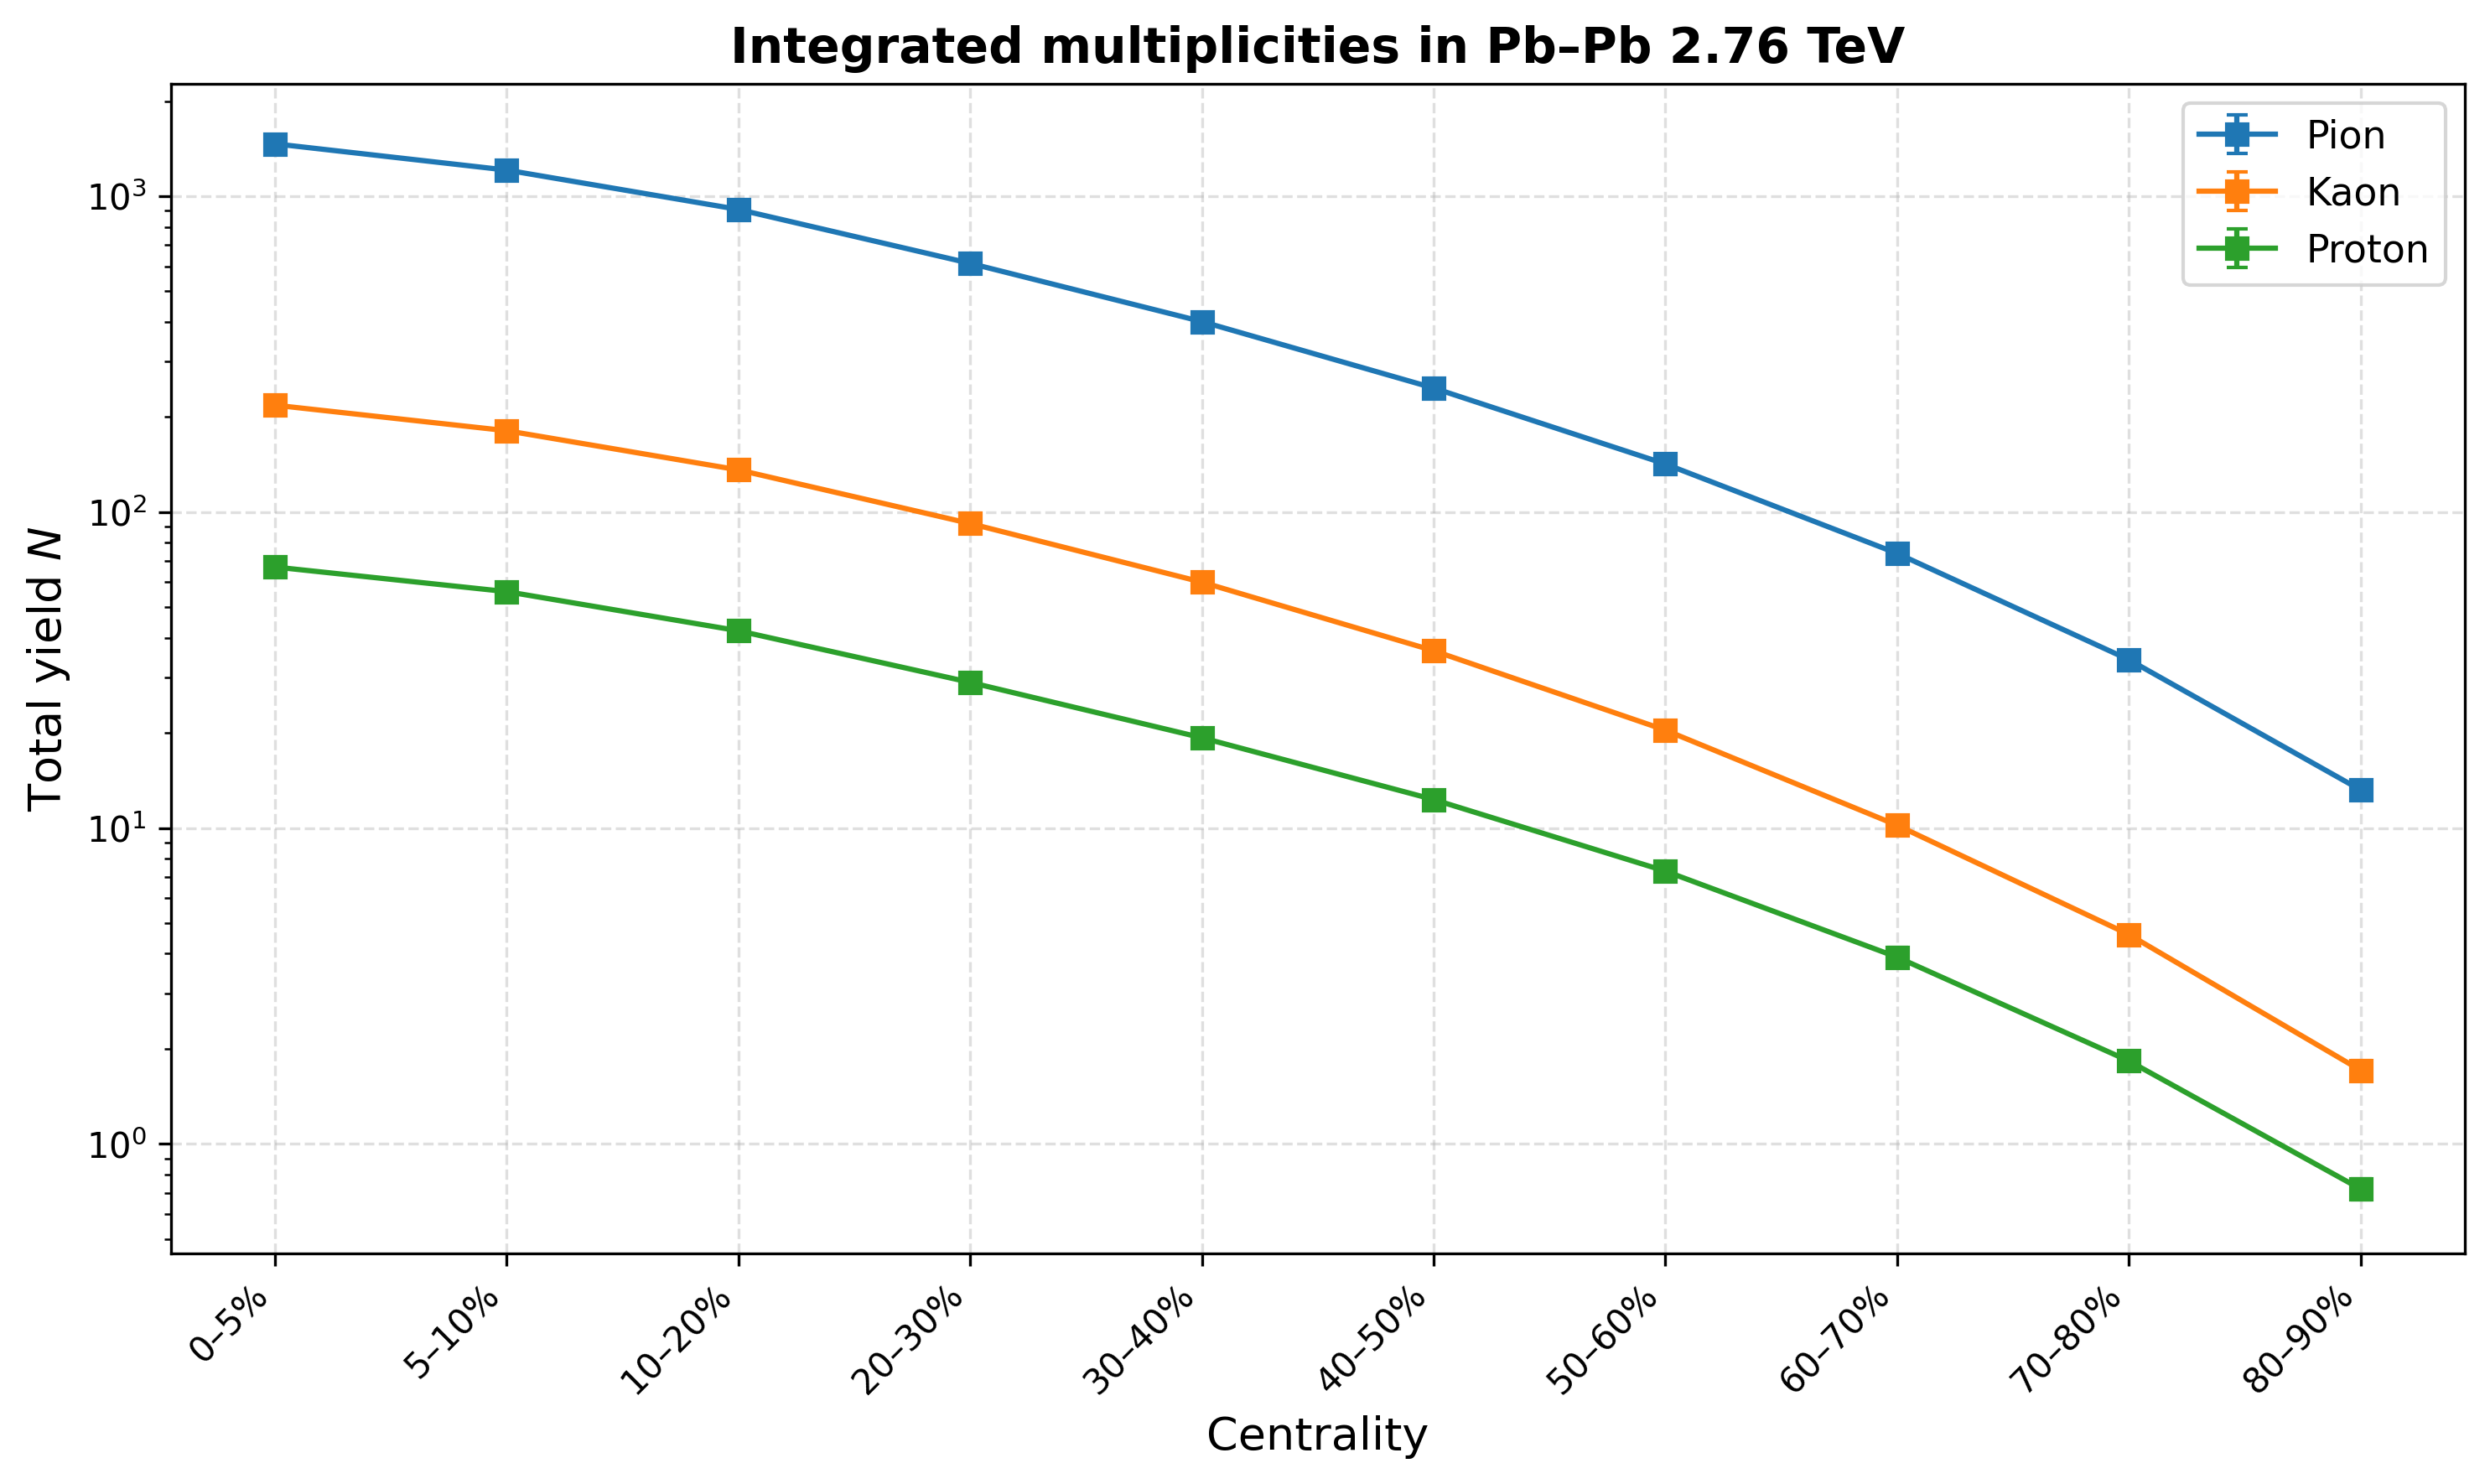

In [26]:
# %%
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

for part in particles:
    N, N_err, mpt, mpt_err = read_PbPb276_extrapolated(part)
    ax.errorbar(x, N, yerr=N_err, fmt='s-', capsize=3, label=part.capitalize())

ax.set_xticks(x)
ax.set_xticklabels(centrality_labels, rotation=45, ha='right')
ax.set_xlabel('Centrality', fontsize=13)
ax.set_ylabel('Total yield $N$', fontsize=13)
ax.set_title('Integrated multiplicities in Pb–Pb 2.76 TeV', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
# Use log scale because N varies widely between pions and protons
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Differential spectra $dN/dp_T$ for all centralities

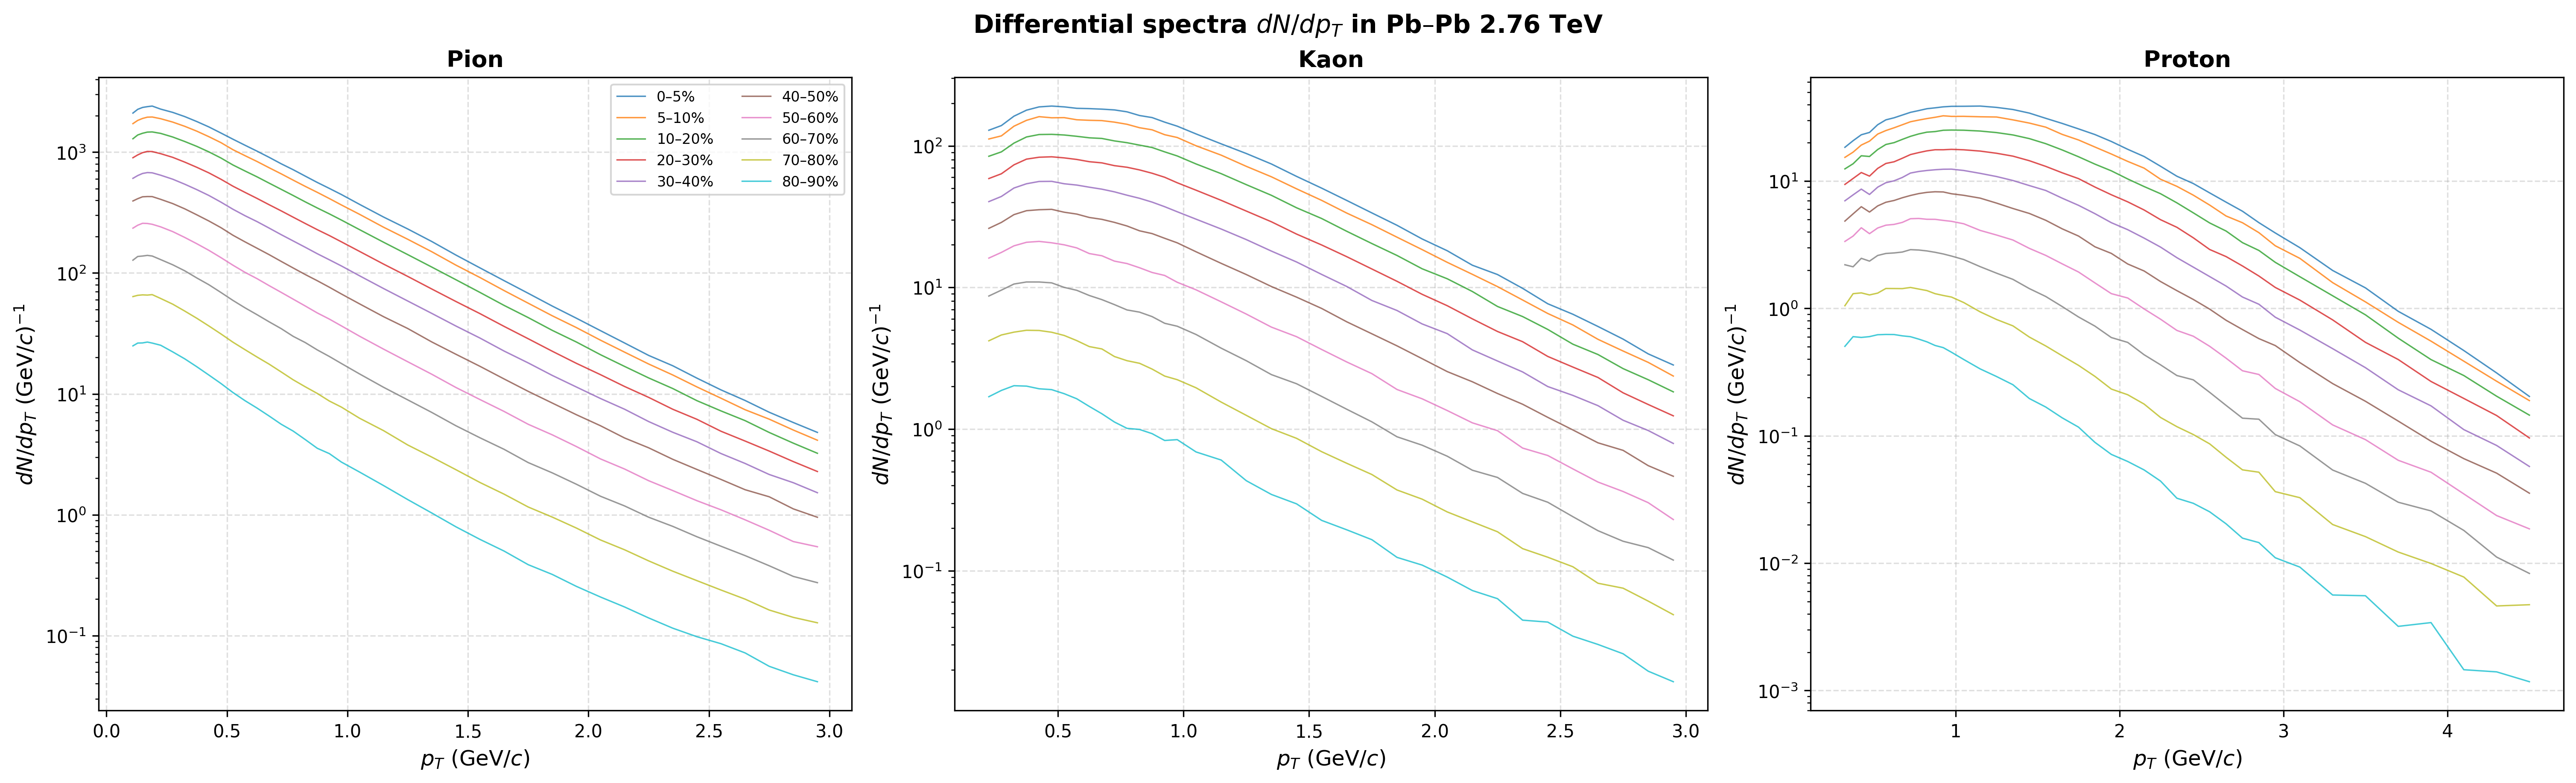

In [27]:
# %%
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300, constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, part in zip(axes, particles):
    # Read spectra for all centralities (indices 0..9)
    pT_list, widths, dNdpT_list, stat, tot = read_PbPb276_spectra(part, centrality_indices=list(range(10)))
    
    for i_cent in range(10):
        pT = pT_list[i_cent]
        dNdpT = dNdpT_list[i_cent]
        ax.plot(pT, dNdpT, color=colors[i_cent], alpha=0.8, lw=0.8,
                label=centrality_labels[i_cent] if part==particles[0] else "")
    
    ax.set_xscale('linear')   # pT in GeV/c
    ax.set_yscale('log')
    ax.set_xlabel(r'$p_T$ (GeV/$c$)', fontsize=12)
    ax.set_ylabel(r'$dN/dp_T$ (GeV/$c$)$^{-1}$', fontsize=12)
    ax.set_title(f'{part.capitalize()}', fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

# Add a single legend for all panels, placed in the first axis
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=8, loc='best', ncol=2)
plt.suptitle('Differential spectra $dN/dp_T$ in Pb–Pb 2.76 TeV', fontsize=14, fontweight='bold')
plt.show()

## Xe+Xe 5.44 TeV

To add later!

### 1.3  Reader for Xe–Xe 5.44 TeV spectra

The tables already contain $\frac{d^2 N}{d\eta dp_T}$, so we only multiply by $\Delta y=1.0$. Each particle and centrality is in a separate table:
- Pions: `Table1.csv`, `Table4.csv`, …, `Table25.csv` (tables 1+3·i)
- Kaons: `Table2.csv`, `Table5.csv`, …, `Table26.csv` (tables 2+3·i)
- Protons: `Table3.csv`, `Table6.csv`, …, `Table27.csv` (tables 3+3·i)

In [ ]:
def read_XeXe_spectra(particle, centrality_indices=None):
    n_cent = 9
    if centrality_indices is None:
        centrality_indices = list(range(n_cent))
    
    n_bins = {'pion': 42, 'kaon': 38, 'proton': 36}
    base_offset = {'pion': 1, 'kaon': 2, 'proton': 3}  # first table number for this particle
    
    pT_all, w_all, dNdpT_all, stat_all, tot_all = [], [], [], [], []
    
    for i_cent in centrality_indices:
        table_num = base_offset[particle] + 3 * i_cent
        fpath = os.path.join(BASE_XeXe, f"Table{table_num}.csv")
        with open(fpath, 'r') as f:
            lines = list(csv.reader(f))
        
        # Data start at line 14 (index 13)
        start = 13
        pT_cent = []; w = []; d2N = []; stat = []; tot = []
        nb = n_bins[particle]
        # For kaons in the two most peripheral centralities one bin is missing.
        if particle == 'kaon' and i_cent >= 7:
            nb = 37
        for j in range(nb):
            row = lines[start + j]
            c = float(row[0])
            lo = float(row[1]); hi = float(row[2])
            val = float(row[3])            # d²N/(dη dpT)
            stat_err = float(row[4])
            sys_err = float(row[6])
            tot_err = np.sqrt(stat_err**2 + sys_err**2)
            pT_cent.append(c)
            w.append(hi - lo)
            d2N.append(val)
            stat.append(stat_err)
            tot.append(tot_err)
        # Append a dummy point if missing to keep rectangular arrays
        if particle == 'kaon' and i_cent >= 7:
            pT_cent.append(pT_cent[-1] + w[-1])
            w.append(w[-1])
            d2N.append(0.0)
            stat.append(0.0)
            tot.append(0.0)
        pT_all.append(np.array(pT_cent))
        w_all.append(np.array(w))
        dNdpT = np.array(d2N) * 1.0   # Δy = 1.0
        dNdpT_all.append(dNdpT)
        stat_all.append(np.array(stat) * 1.0)
        tot_all.append(np.array(tot) * 1.0)
    
    return pT_all, w_all, dNdpT_all, stat_all, tot_all

### 1.4  Extrapolated values for Xe–Xe
 
These numbers are taken from Eur. Phys. J. C 81, 584 (2021). They correspond to the nine centrality classes 0‑5% … 70‑90%.

In [ ]:
#### Caution: this was hard-coded. We need to extract from Tables
# %%
def XeXe_extrapolated_values(particle):
    if particle == 'pion':
        N = np.array([1002.67, 808.76, 620.47, 426.77, 287.20, 182.89, 111.05, 61.23, 21.43])
        N_stat = np.array([0.39, 0.41, 0.24, 0.21, 0.16, 0.13, 0.10, 0.07, 0.03])
        N_sys = np.array([57.16, 45.34, 34.71, 24.14, 16.48, 10.87, 6.62, 3.77, 1.39])
        meanpT = np.array([0.54831, 0.55056, 0.54831, 0.54157, 0.53033, 0.52134, 0.50561, 0.49213, 0.46741])
        mpt_err = np.full_like(meanpT, 0.01)   # estimated uncertainty from digitisation
    elif particle == 'kaon':
        N = np.array([149.37, 123.58, 95.38, 66.15, 44.02, 27.80, 16.25, 8.83, 2.95])
        N_stat = np.array([0.21, 0.22, 0.14, 0.11, 0.09, 0.07, 0.05, 0.04, 0.01])
        N_sys = np.array([14.07, 11.01, 7.94, 5.44, 3.61, 2.25, 1.33, 0.77, 0.26])
        meanpT = np.array([0.90716, 0.91064, 0.906, 0.89439, 0.8793, 0.85725, 0.83056, 0.80271, 0.76093])
        mpt_err = np.full_like(meanpT, 0.01)
    elif particle == 'proton':
        N = np.array([46.21, 37.79, 29.26, 20.74, 14.31, 9.38, 5.82, 3.26, 1.17])
        N_stat = np.array([0.09, 0.09, 0.06, 0.05, 0.04, 0.03, 0.02, 0.02, 0.01])
        N_sys = np.array([4.73, 3.8, 3.02, 2.1, 1.48, 0.9, 0.61, 0.3, 0.14])
        meanpT = np.array([1.41173, 1.40495, 1.38559, 1.34693, 1.28926, 1.23976, 1.19484, 1.12157, 1.01481])
        mpt_err = np.full_like(meanpT, 0.01)
    else:
        raise ValueError("Unknown particle")
    N_err = np.sqrt(N_stat**2 + N_sys**2)
    return N, N_err, meanpT, mpt_err